In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
# Use inline backend for Jupyter — remove Agg override used in the .py script
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from IPython.display import Image, display

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
class PowerConsumptionPipeline:
    """
    OOP-based data engineering pipeline for GRD-05:
    Micro-Grid Voltage Stability Analysis using the UCI
    Individual Household Electric Power Consumption dataset.

    Modules
    -------
    1. load_data()           — Data Ingestion
    2. clean_data()          — Data Cleaning & Feature Engineering
    3. apply_unique_filter() — Voltage Stability Window Filter (VSWF)
    4. compute_statistics()  — Descriptive, Distribution & Comparative Analytics (NumPy)
    5. correlation_analysis()— Pearson Correlation Matrix
    6. plot_static()         — 5 Static Visualizations
    7. plot_animated()       — 2 Animated Visualizations
    8. run()                 — Master pipeline orchestrator
    """

    RAW_PATH   = 'data/dataset_original.csv'
    CLEAN_PATH = 'data/dataset_cleaned.csv'
    OUT_DIR    = 'outputs/'

    def __init__(self):
        self.df_raw            = None
        self.df_clean          = None
        self.df_filtered       = None
        self.df_all_2008       = None
        self.stats_results     = {}
        self.corr_matrix       = None
        self.weekday_data      = None
        self.weekend_data      = None
        self.n_unstable_events = 0

        os.makedirs(self.OUT_DIR, exist_ok=True)
        os.makedirs('data/', exist_ok=True)

    # =========================================================================
    # MODULE 1 — DATA INGESTION
    # =========================================================================
    def load_data(self):
        """
        Load the raw household power consumption CSV.

        The file uses semicolons as delimiters and '?' for missing values.
        Date and Time columns are merged into a single Datetime index.
        """
        print('\n' + '═'*60)
        print('  MODULE 1 — DATA INGESTION')
        print('═'*60)
        try:
            self.df_raw = pd.read_csv(
                self.RAW_PATH,
                sep=',',
                na_values=['?'],
                dtype={
                    'Global_active_power'   : 'float32',
                    'Global_reactive_power' : 'float32',
                    'Voltage'               : 'float32',
                    'Global_intensity'      : 'float32',
                    'Sub_metering_1'        : 'float32',
                    'Sub_metering_2'        : 'float32',
                    'Sub_metering_3'        : 'float32',
                },
            )
            self.df_raw['Datetime'] = pd.to_datetime(
                self.df_raw['Date'] + ' ' + self.df_raw['Time'],
                dayfirst=True
            )
            self.df_raw = self.df_raw.drop(columns=['Date', 'Time'])
            self.df_raw = self.df_raw.set_index('Datetime')
            self.df_raw.sort_index(inplace=True)

            print(f'  ✔  Records loaded  : {len(self.df_raw):>12,}')
            print(f'  ✔  Date range      : {self.df_raw.index.min()}  →  {self.df_raw.index.max()}')
            print(f'  ✔  Columns         : {list(self.df_raw.columns)}')
            print(f'\n  Missing values per column:')
            missing = self.df_raw.isnull().sum()
            for col, n in missing.items():
                pct = n / len(self.df_raw) * 100
                print(f'      {col:<30} {n:>7,}  ({pct:.2f}%)')

        except FileNotFoundError:
            raise FileNotFoundError(
                f"\n  ✘  Dataset not found at '{self.RAW_PATH}'.\n"
                '     Download from Kaggle and place the CSV in the data/ folder.'
            )
        except Exception as exc:
            raise RuntimeError(f'  ✘  Ingestion error: {exc}')

        return self

    # =========================================================================
    # MODULE 2 — DATA CLEANING & FEATURE ENGINEERING
    # =========================================================================
    def clean_data(self):
        """
        Automated cleaning pipeline:
          Step 1 – Remove duplicate timestamps
          Step 2 – Impute missing values via time-based interpolation
          Step 3 – Drop physically impossible readings
          Step 4 – Engineer derived features
        """
        print('\n' + '═'*60)
        print('  MODULE 2 — DATA CLEANING')
        print('═'*60)
        try:
            df = self.df_raw.copy()
            n0 = len(df)

            # ── Step 1: duplicates
            df = df[~df.index.duplicated(keep='first')]
            n_dup = n0 - len(df)
            print(f'  ✔  Duplicates removed            : {n_dup:,}')

            # ── Step 2: missing value imputation
            n_missing = int(df.isnull().sum().sum())
            df = df.interpolate(method='time', limit=30)
            df.ffill(inplace=True)
            df.bfill(inplace=True)
            print(f'  ✔  Missing values imputed        : {n_missing:,}')

            # ── Step 3: domain-constraint filtering
            before = len(df)
            df = df[df['Voltage'].between(200.0, 260.0)]
            df = df[df['Global_active_power'] >= 0.0]
            df = df[df['Global_intensity'].between(0.0, 50.0)]
            df = df[df['Global_reactive_power'] >= 0.0]
            print(f'  ✔  Out-of-range rows removed     : {before - len(df):,}')

            # ── Step 4: feature engineering
            df['Hour']      = df.index.hour
            df['Month']     = df.index.month
            df['Year']      = df.index.year
            df['DayOfWeek'] = df.index.dayofweek
            df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
            df['Sub_metering_rest'] = np.maximum(
                0.0,
                df['Global_active_power'] * 1000.0 / 60.0
                - df['Sub_metering_1']
                - df['Sub_metering_2']
                - df['Sub_metering_3'],
            )
            df['Load_period'] = pd.cut(
                df['Hour'],
                bins=[0, 6, 12, 18, 24],
                labels=['Night (0-6h)', 'Morning (6-12h)',
                        'Afternoon (12-18h)', 'Evening (18-24h)'],
                right=False,
            )

            self.df_clean = df
            df.drop(columns=['Hour','Month','Year','DayOfWeek',
                             'IsWeekend','Load_period',
                             'Sub_metering_rest'], errors='ignore').to_csv(self.CLEAN_PATH)

            print(f'  ✔  Final clean records           : {len(self.df_clean):,}')
            print(f"  ✔  Saved to '{self.CLEAN_PATH}'")

        except Exception as exc:
            raise RuntimeError(f'  ✘  Cleaning error: {exc}')

        return self

    # =========================================================================
    # UNIQUE FILTER — VOLTAGE STABILITY WINDOW FILTER (VSWF)
    # =========================================================================
    def apply_unique_filter(self, year: int = 2008,
                            window: int = 60,
                            sigma: float = 2.0):
        """
        Voltage Stability Window Filter (VSWF) — Unique Programmatic Filter

        Algorithm
        ---------
        1. Extract Year-2008 sub-dataset for temporal uniqueness.
        2. Compute per-minute rolling mean μ_roll(t) and rolling std σ_roll(t)
           over a 60-sample window.
        3. Flag record t as UNSTABLE if:
               | V(t) − μ_roll(t) | > θ · σ_roll(t)
           where θ = sigma threshold (default 2.0).
        4. Compute Voltage Stability Index: VSI(t) = 1 − σ_roll(t)/μ_roll(t)
        5. Retain only STABLE records for downstream analytics.
        """
        print('\n' + '═'*60)
        print('  UNIQUE FILTER — VOLTAGE STABILITY WINDOW FILTER (VSWF)')
        print('═'*60)
        try:
            df = self.df_clean[self.df_clean['Year'] == year].copy()
            print(f'  ✔  Year {year} slice size          : {len(df):,} records')

            roll_mean = (df['Voltage']
                         .rolling(window=window, center=True, min_periods=1)
                         .mean())
            roll_std  = (df['Voltage']
                         .rolling(window=window, center=True, min_periods=1)
                         .std()
                         .fillna(df['Voltage'].std()))

            lower = roll_mean - sigma * roll_std
            upper = roll_mean + sigma * roll_std
            stable_mask = df['Voltage'].between(lower, upper)

            df['Roll_V_Mean']    = roll_mean
            df['Roll_V_Std']     = roll_std
            df['VSI']            = 1.0 - (roll_std / roll_mean)
            df['Voltage_Stable'] = stable_mask

            self.n_unstable_events = int((~stable_mask).sum())
            self.df_all_2008  = df.copy()
            self.df_filtered  = df[stable_mask].copy()

            pct_unstable = self.n_unstable_events / len(df) * 100
            print(f'  ✔  Instability events detected   : '
                  f'{self.n_unstable_events:,}  ({pct_unstable:.2f}%)')
            print(f'  ✔  Stable records retained       : {len(self.df_filtered):,}')
            print(f"  ✔  Mean VSI (stable epochs)      : "
                  f"{self.df_filtered['VSI'].mean():.6f}")

        except Exception as exc:
            raise RuntimeError(f'  ✘  VSWF error: {exc}')

        return self

    # =========================================================================
    # MODULE 3 — STATISTICAL ANALYSIS (NumPy)
    # =========================================================================
    def compute_statistics(self):
        """Descriptive, distribution, and comparative statistics using NumPy."""
        print('\n' + '═'*60)
        print('  MODULE 3 — STATISTICAL ANALYSIS (NumPy)')
        print('═'*60)
        try:
            df = self.df_filtered
            features = [
                'Global_active_power', 'Global_reactive_power',
                'Voltage', 'Global_intensity',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
            ]
            results = {}
            for col in features:
                arr = df[col].dropna().to_numpy(dtype=np.float64)
                q1, q3 = np.percentile(arr, [25, 75])
                iqr = q3 - q1
                results[col] = {
                    'Mean'     : np.mean(arr),
                    'Median'   : np.median(arr),
                    'Std Dev'  : np.std(arr, ddof=1),
                    'Variance' : np.var(arr, ddof=1),
                    'Min'      : np.min(arr),
                    'Max'      : np.max(arr),
                    'Q1'       : q1,
                    'Q3'       : q3,
                    'IQR'      : iqr,
                    'Skewness' : float(stats.skew(arr)),
                    'Kurtosis' : float(stats.kurtosis(arr)),
                }
            self.stats_results = results
            stats_df = pd.DataFrame(results).T.round(4)
            print(stats_df[['Mean','Median','Std Dev','Variance',
                             'Skewness','Kurtosis']].to_string())

            print('\n  ── Comparative Analysis: Weekday vs Weekend ──────────')
            wd = df[df['DayOfWeek'] < 5 ]['Global_active_power'].to_numpy(dtype=np.float64)
            we = df[df['DayOfWeek'] >= 5]['Global_active_power'].to_numpy(dtype=np.float64)
            self.weekday_data = wd
            self.weekend_data = we

            print(f'  Weekday  — Mean: {np.mean(wd):.4f} kW   '
                  f'Std: {np.std(wd):.4f} kW   n={len(wd):,}')
            print(f'  Weekend  — Mean: {np.mean(we):.4f} kW   '
                  f'Std: {np.std(we):.4f} kW   n={len(we):,}')

            t_stat, p_val = stats.ttest_ind(wd, we, equal_var=False)
            sig = 'SIGNIFICANT ✔' if p_val < 0.05 else 'not significant'
            print(f'  Welch t-test → t = {t_stat:.4f},  p = {p_val:.6f}  [{sig}]')

        except Exception as exc:
            raise RuntimeError(f'  ✘  Statistics error: {exc}')

        return self

    # =========================================================================
    # MODULE 4 — CORRELATION ANALYSIS
    # =========================================================================
    def correlation_analysis(self):
        """Pearson correlation matrix for all power-quality variables."""
        print('\n' + '═'*60)
        print('  MODULE 4 — CORRELATION ANALYSIS')
        print('═'*60)
        try:
            features = [
                'Global_active_power', 'Global_reactive_power',
                'Voltage', 'Global_intensity',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
            ]
            self.corr_matrix = self.df_filtered[features].corr(method='pearson')
            print(self.corr_matrix.round(4).to_string())
        except Exception as exc:
            raise RuntimeError(f'  ✘  Correlation error: {exc}')

        return self

    # =========================================================================
    # MODULE 5a — STATIC VISUALIZATIONS (5 plots)
    # =========================================================================
    def plot_static(self):
        """
        Generate five static visualizations and display them inline.
          Fig 1 — Voltage distribution histogram
          Fig 2 — Global Active Power boxplot by load period
          Fig 3 — Voltage vs Active Power scatter (colored by current)
          Fig 4 — Pearson correlation heatmap
          Fig 5 — Weekday vs Weekend KDE overlay
        """
        print('\n' + '═'*60)
        print('  MODULE 5a — STATIC VISUALIZATIONS')
        print('═'*60)
        try:
            df   = self.df_filtered
            plt.style.use('seaborn-v0_8-whitegrid')
            BLUE, ORANGE, RED, PURPLE = '#1565C0','#FF7043','#C62828','#6A1B9A'

            # ── Fig 1: Voltage Histogram
            fig, ax = plt.subplots(figsize=(9, 4.5))
            v_arr = df['Voltage'].to_numpy(dtype=np.float64)
            ax.hist(v_arr, bins=100, color=BLUE, edgecolor='white', alpha=0.82)
            ax.axvline(np.mean(v_arr),   color=RED,    lw=2, ls='--',
                       label=f'Mean = {np.mean(v_arr):.2f} V')
            ax.axvline(np.median(v_arr), color=ORANGE, lw=2, ls='-.',
                       label=f'Median = {np.median(v_arr):.2f} V')
            ax.axvline(230, color='green', lw=1.5, ls=':',
                       label='EU Nominal 230 V')
            ax.set_title('Voltage Distribution — 2008 VSWF-Stable Epochs',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel('Voltage (V)'); ax.set_ylabel('Frequency')
            ax.legend(fontsize=9)
            plt.tight_layout()
            path1 = f'{self.OUT_DIR}fig1_voltage_histogram.png'
            fig.savefig(path1, dpi=150)
            plt.show()
            print(f'  ✔  Saved: {path1}')

            # ── Fig 2: Boxplot by Load Period
            fig, ax = plt.subplots(figsize=(9, 5))
            periods = ['Night (0-6h)','Morning (6-12h)',
                       'Afternoon (12-18h)','Evening (18-24h)']
            data_bp = [
                df[df['Load_period'] == p]['Global_active_power']
                  .to_numpy(dtype=np.float64)
                for p in periods
            ]
            bp = ax.boxplot(data_bp, labels=['Night','Morning','Afternoon','Evening'],
                            patch_artist=True, notch=True, showfliers=False)
            clrs = [BLUE, '#42A5F5', ORANGE, PURPLE]
            for patch, c in zip(bp['boxes'], clrs):
                patch.set_facecolor(c); patch.set_alpha(0.72)
            ax.set_title('Global Active Power Distribution by Load Period (2008)',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel('Time-of-Day Period'); ax.set_ylabel('Active Power (kW)')
            plt.tight_layout()
            path2 = f'{self.OUT_DIR}fig2_power_boxplot_by_period.png'
            fig.savefig(path2, dpi=150)
            plt.show()
            print(f'  ✔  Saved: {path2}')

            # ── Fig 3: Scatter — Voltage vs Active Power
            fig, ax = plt.subplots(figsize=(9, 5.5))
            samp = df.sample(min(8000, len(df)), random_state=42)
            sc = ax.scatter(
                samp['Global_active_power'], samp['Voltage'],
                c=samp['Global_intensity'], cmap='plasma',
                alpha=0.35, s=4, rasterized=True,
            )
            plt.colorbar(sc, ax=ax, label='Global Intensity (A)')
            m, b = np.polyfit(
                samp['Global_active_power'].to_numpy(dtype=np.float64),
                samp['Voltage'].to_numpy(dtype=np.float64), 1
            )
            xr = np.linspace(samp['Global_active_power'].min(),
                             samp['Global_active_power'].max(), 200)
            ax.plot(xr, m*xr + b, color=RED, lw=2,
                    label=f'OLS: V = {m:.3f}·P + {b:.2f}')
            ax.set_title('Voltage vs. Global Active Power (2008 VSWF Slice)',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel('Global Active Power (kW)')
            ax.set_ylabel('Voltage (V)')
            ax.legend(fontsize=9)
            plt.tight_layout()
            path3 = f'{self.OUT_DIR}fig3_voltage_vs_power_scatter.png'
            fig.savefig(path3, dpi=150)
            plt.show()
            print(f'  ✔  Saved: {path3}')

            # ── Fig 4: Correlation Heatmap
            fig, ax = plt.subplots(figsize=(8, 6.5))
            short_labels = ['GAP','GRP','V','GI','SM1','SM2','SM3']
            corr_renamed = self.corr_matrix.copy()
            corr_renamed.index   = short_labels
            corr_renamed.columns = short_labels
            sns.heatmap(
                corr_renamed, annot=True, fmt='.3f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.6, ax=ax, annot_kws={'size': 9},
            )
            ax.set_title('Pearson Correlation Matrix — Power Variables (2008)',
                         fontsize=12, fontweight='bold')
            ax.text(0, -0.5,
                    'GAP=Global Active Power  GRP=Global Reactive Power  '
                    'V=Voltage  GI=Global Intensity  SM=Sub-metering',
                    fontsize=7, transform=ax.transData)
            plt.tight_layout()
            path4 = f'{self.OUT_DIR}fig4_correlation_heatmap.png'
            fig.savefig(path4, dpi=150)
            plt.show()
            print(f'  ✔  Saved: {path4}')

            # ── Fig 5: Weekday vs Weekend KDE
            fig, ax = plt.subplots(figsize=(9, 4.5))
            step = max(1, len(self.weekday_data) // 20000)
            kde_wd = stats.gaussian_kde(self.weekday_data[::step])
            kde_we = stats.gaussian_kde(self.weekend_data[::step])
            x_kd  = np.linspace(0, 8, 500)
            ax.fill_between(x_kd, kde_wd(x_kd), alpha=0.55,
                            color=BLUE,  label=f'Weekday  (n={len(self.weekday_data):,})')
            ax.fill_between(x_kd, kde_we(x_kd), alpha=0.55,
                            color=RED,   label=f'Weekend  (n={len(self.weekend_data):,})')
            ax.set_title('Weekday vs Weekend Power Consumption — KDE (2008)',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel('Global Active Power (kW)')
            ax.set_ylabel('Probability Density')
            ax.legend(fontsize=9)
            plt.tight_layout()
            path5 = f'{self.OUT_DIR}fig5_weekday_weekend_kde.png'
            fig.savefig(path5, dpi=150)
            plt.show()
            print(f'  ✔  Saved: {path5}')

        except Exception as exc:
            raise RuntimeError(f'  ✘  Static-plot error: {exc}')

        return self

    # =========================================================================
    # MODULE 5b — ANIMATED VISUALIZATIONS (2 animations)
    # =========================================================================
    def plot_animated(self):
        """
        Generate two animated GIF visualizations and display them inline.
          Anim 1 — Daily mean voltage time-series build-up (2008)
          Anim 2 — Hourly average power-consumption bar cycle
        """
        print('\n' + '═'*60)
        print('  MODULE 5b — ANIMATED VISUALIZATIONS')
        print('═'*60)
        try:
            # ── Animation 1: Daily Voltage Rolling Build
            daily_v = (self.df_all_2008.resample('D')['Voltage']
                       .mean().reset_index())
            daily_v.columns = ['Date', 'Voltage']

            fig, ax = plt.subplots(figsize=(11, 4.5))
            ax.set_xlim(daily_v['Date'].min(), daily_v['Date'].max())
            vmin = daily_v['Voltage'].min() - 2
            vmax = daily_v['Voltage'].max() + 2
            ax.set_ylim(vmin, vmax)
            ax.axhline(230, color='green', lw=1.2, ls='--', label='230 V nominal')
            ax.set_title('Daily Mean Voltage — Year 2008 (VSWF Annotated)',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Date'); ax.set_ylabel('Mean Voltage (V)')
            ax.legend(fontsize=8)
            line,  = ax.plot([], [], lw=2.0, color='#1565C0')
            txt    = ax.text(0.02, 0.93, '', transform=ax.transAxes,
                             fontsize=8, color='#C62828')

            def _update_v(frame):
                xs = daily_v['Date'].iloc[:frame+1]
                ys = daily_v['Voltage'].iloc[:frame+1]
                line.set_data(xs, ys)
                for coll in ax.collections:
                    coll.remove()
                ax.fill_between(xs, ys, vmin, alpha=0.12, color='#1565C0')
                txt.set_text(f'Day {frame+1}/{len(daily_v)}')
                return line, txt

            ani1 = animation.FuncAnimation(
                fig, _update_v, frames=len(daily_v),
                interval=60, blit=False
            )
            p_a1 = f'{self.OUT_DIR}anim1_daily_voltage_2008.gif'
            ani1.save(p_a1, writer='pillow', fps=14)
            plt.close()
            display(Image(p_a1))
            print(f'  ✔  Saved: {p_a1}')

            # ── Animation 2: Hourly Power Cycle
            hourly = (self.df_filtered
                      .groupby('Hour')['Global_active_power']
                      .mean().reset_index())

            HOUR_COLORS = {
                **{h: '#1A237E' for h in range(0, 6)},
                **{h: '#42A5F5' for h in range(6, 12)},
                **{h: '#FF7043' for h in range(12, 18)},
                **{h: '#6A1B9A' for h in range(18, 24)},
            }

            fig, ax = plt.subplots(figsize=(10, 4.5))

            def _update_bar(frame):
                ax.cla()
                sub = hourly.iloc[:frame+1]
                colors = [HOUR_COLORS[int(h)] for h in sub['Hour']]
                ax.bar(sub['Hour'], sub['Global_active_power'],
                       color=colors, edgecolor='white', alpha=0.88)
                ax.set_xlim(-0.7, 23.7)
                ax.set_ylim(0, hourly['Global_active_power'].max() * 1.25)
                ax.set_xticks(range(0, 24))
                ax.set_xlabel('Hour of Day'); ax.set_ylabel('Mean Active Power (kW)')
                ax.set_title('Hourly Average Power Consumption Cycle — 2008',
                             fontsize=12, fontweight='bold')
                patches = [
                    mpatches.Patch(color='#1A237E', label='Night (0-6h)'),
                    mpatches.Patch(color='#42A5F5', label='Morning (6-12h)'),
                    mpatches.Patch(color='#FF7043', label='Afternoon (12-18h)'),
                    mpatches.Patch(color='#6A1B9A', label='Evening (18-24h)'),
                ]
                ax.legend(handles=patches, fontsize=7, loc='upper left')
                return []

            ani2 = animation.FuncAnimation(
                fig, _update_bar, frames=len(hourly),
                interval=160, blit=False
            )
            p_a2 = f'{self.OUT_DIR}anim2_hourly_power_cycle.gif'
            ani2.save(p_a2, writer='pillow', fps=5)
            plt.close()
            display(Image(p_a2))
            print(f'  ✔  Saved: {p_a2}')

        except Exception as exc:
            raise RuntimeError(f'  ✘  Animation error: {exc}')

        return self

    # =========================================================================
    # MASTER PIPELINE
    # =========================================================================
    def run(self):
        """Execute the complete data engineering pipeline end-to-end."""
        print('\n' + '█'*60)
        print('  GRD-05 — MICRO-GRID VOLTAGE STABILITY PIPELINE')
        print('  Household Electric Power Consumption  |  2026')
        print('█'*60)

        (self
         .load_data()
         .clean_data()
         .apply_unique_filter(year=2008, window=60, sigma=2.0)
         .compute_statistics()
         .correlation_analysis()
         .plot_static()
         .plot_animated())

        print('\n' + '█'*60)
        print('  ✅  PIPELINE COMPLETE')
        print(f'  Outputs → {self.OUT_DIR}')
        print('█'*60)


print('Class PowerConsumptionPipeline defined successfully.')

Class PowerConsumptionPipeline defined successfully.



████████████████████████████████████████████████████████████
  GRD-05 — MICRO-GRID VOLTAGE STABILITY PIPELINE
  Household Electric Power Consumption  |  2026
████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
  MODULE 1 — DATA INGESTION
════════════════════════════════════════════════════════════
  ✔  Records loaded  :    1,048,575
  ✔  Date range      : 2006-12-16 17:24:00  →  2008-12-13 21:38:00
  ✔  Columns         : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

  Missing values per column:
      Global_active_power              4,069  (0.39%)
      Global_reactive_power            4,069  (0.39%)
      Voltage                          4,069  (0.39%)
      Global_intensity                 4,069  (0.39%)
      Sub_metering_1                   4,069  (0.39%)
      Sub_metering_2                   4,069  (0.39%)
      Sub_meter

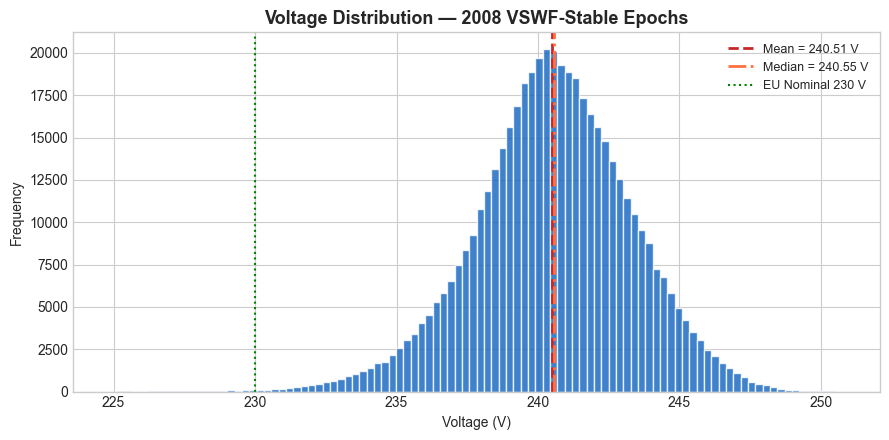

  ✔  Saved: outputs/fig1_voltage_histogram.png


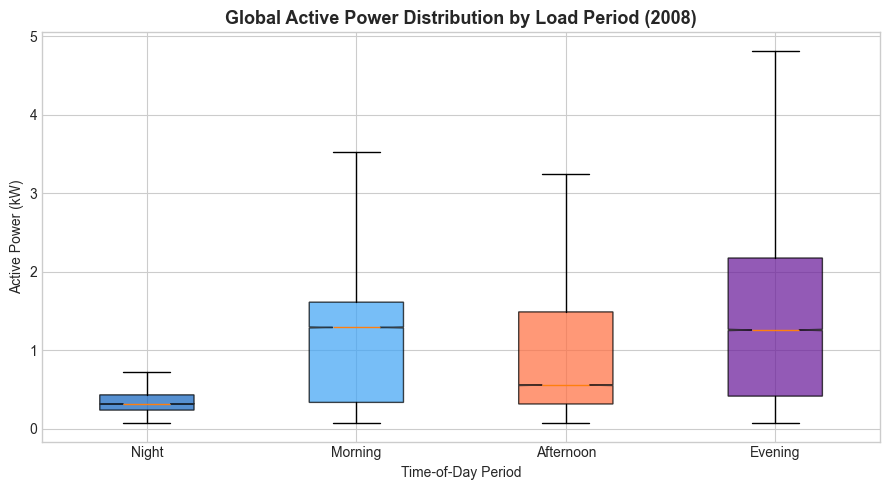

  ✔  Saved: outputs/fig2_power_boxplot_by_period.png


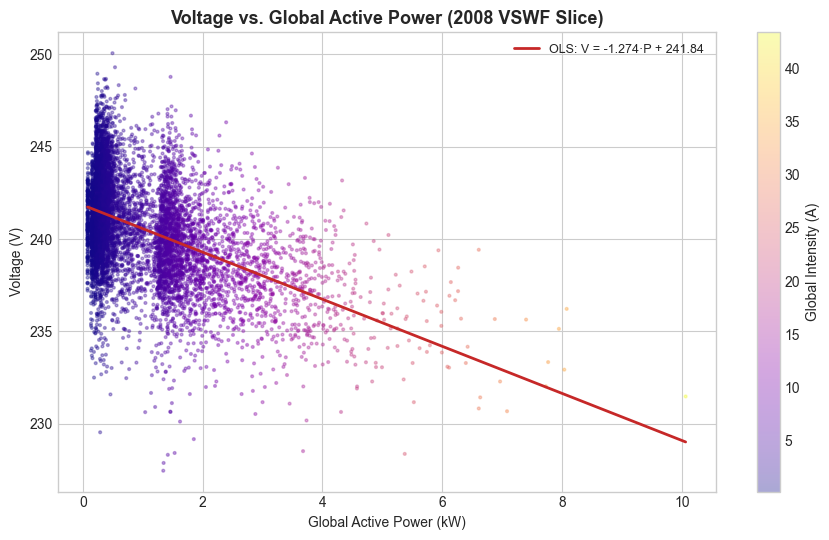

  ✔  Saved: outputs/fig3_voltage_vs_power_scatter.png


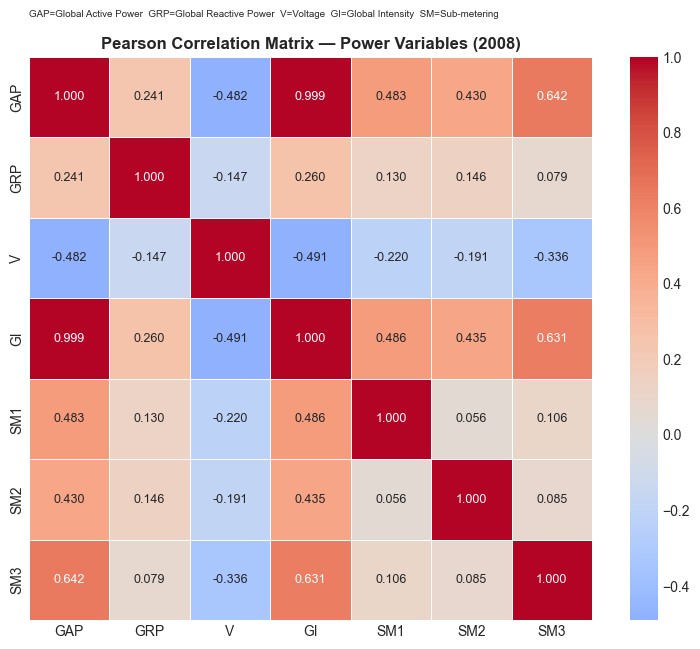

  ✔  Saved: outputs/fig4_correlation_heatmap.png


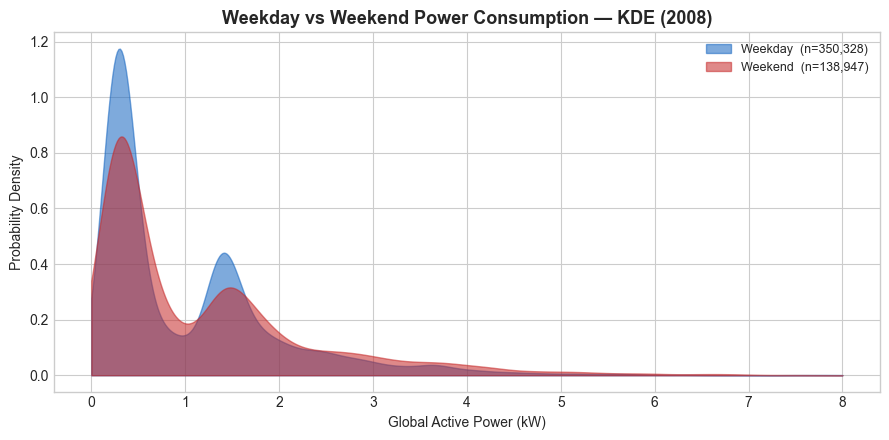

  ✔  Saved: outputs/fig5_weekday_weekend_kde.png

════════════════════════════════════════════════════════════
  MODULE 5b — ANIMATED VISUALIZATIONS
════════════════════════════════════════════════════════════


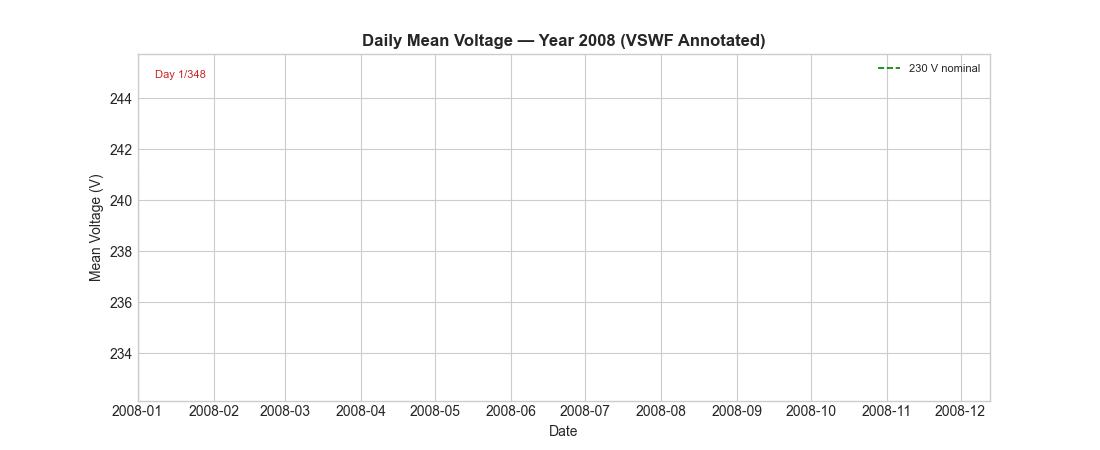

  ✔  Saved: outputs/anim1_daily_voltage_2008.gif


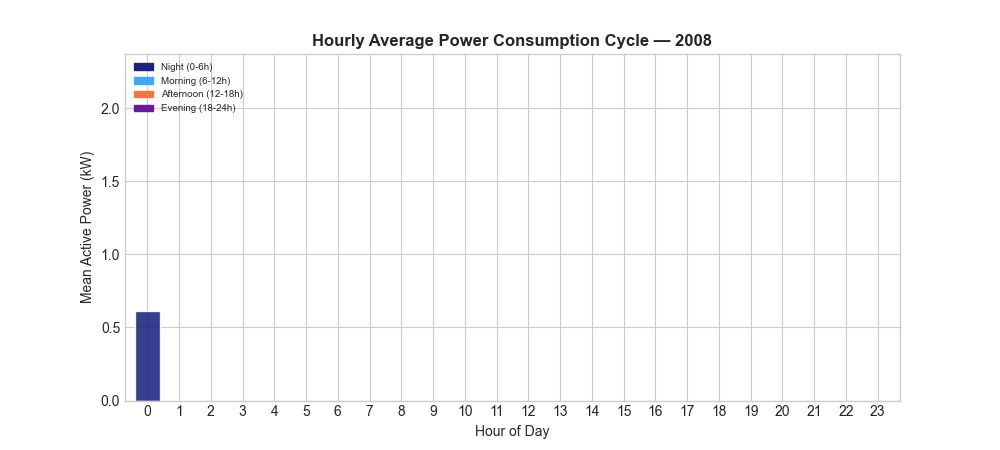

  ✔  Saved: outputs/anim2_hourly_power_cycle.gif

████████████████████████████████████████████████████████████
  ✅  PIPELINE COMPLETE
  Outputs → outputs/
████████████████████████████████████████████████████████████


In [3]:
pipeline = PowerConsumptionPipeline()
pipeline.run()

In [4]:
# Step-by-step execution (run this cell instead of pipeline.run() above)
p = PowerConsumptionPipeline()
p.load_data()


════════════════════════════════════════════════════════════
  MODULE 1 — DATA INGESTION
════════════════════════════════════════════════════════════
  ✔  Records loaded  :    1,048,575
  ✔  Date range      : 2006-12-16 17:24:00  →  2008-12-13 21:38:00
  ✔  Columns         : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

  Missing values per column:
      Global_active_power              4,069  (0.39%)
      Global_reactive_power            4,069  (0.39%)
      Voltage                          4,069  (0.39%)
      Global_intensity                 4,069  (0.39%)
      Sub_metering_1                   4,069  (0.39%)
      Sub_metering_2                   4,069  (0.39%)
      Sub_metering_3                   4,069  (0.39%)


In [5]:
p.clean_data()


════════════════════════════════════════════════════════════
  MODULE 2 — DATA CLEANING
════════════════════════════════════════════════════════════
  ✔  Duplicates removed            : 0
  ✔  Missing values imputed        : 28,483
  ✔  Out-of-range rows removed     : 0
  ✔  Final clean records           : 1,048,575
  ✔  Saved to 'data/dataset_cleaned.csv'


In [6]:
p.apply_unique_filter(year=2008, window=60, sigma=2.0)


════════════════════════════════════════════════════════════
  UNIQUE FILTER — VOLTAGE STABILITY WINDOW FILTER (VSWF)
════════════════════════════════════════════════════════════
  ✔  Year 2008 slice size          : 500,979 records
  ✔  Instability events detected   : 11,704  (2.34%)
  ✔  Stable records retained       : 489,275
  ✔  Mean VSI (stable epochs)      : 0.995251


In [7]:
p.compute_statistics()


════════════════════════════════════════════════════════════
  MODULE 3 — STATISTICAL ANALYSIS (NumPy)
════════════════════════════════════════════════════════════
                           Mean   Median  Std Dev  Variance  Skewness  Kurtosis
Global_active_power      1.0548    0.548   1.0486    1.0996    1.8129    4.2809
Global_reactive_power    0.1184    0.096   0.1099    0.0121    1.2935    2.7989
Voltage                240.5088  240.550   2.7818    7.7383   -0.2558    0.5119
Global_intensity         4.4837    2.400   4.4153   19.4946    1.8683    4.6456
Sub_metering_1           1.0781    0.000   6.0370   36.4456    6.0056   35.9606
Sub_metering_2           1.2473    0.000   5.6825   32.2908    6.9829   55.6809
Sub_metering_3           5.9994    1.000   8.2032   67.2925    0.8456   -1.0926

  ── Comparative Analysis: Weekday vs Weekend ──────────
  Weekday  — Mean: 1.0126 kW   Std: 0.9904 kW   n=350,328
  Weekend  — Mean: 1.1610 kW   Std: 1.1762 kW   n=138,947
  Welch t-test → t = 

In [8]:
p.correlation_analysis()


════════════════════════════════════════════════════════════
  MODULE 4 — CORRELATION ANALYSIS
════════════════════════════════════════════════════════════
                       Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
Global_active_power                 1.0000                 0.2410  -0.4820            0.9990          0.4827          0.4301          0.6424
Global_reactive_power               0.2410                 1.0000  -0.1471            0.2604          0.1302          0.1461          0.0787
Voltage                            -0.4820                -0.1471   1.0000           -0.4910         -0.2203         -0.1906         -0.3362
Global_intensity                    0.9990                 0.2604  -0.4910            1.0000          0.4862          0.4355          0.6313
Sub_metering_1                      0.4827                 0.1302  -0.2203            0.4862          1.0000          0.0562          0.10


════════════════════════════════════════════════════════════
  MODULE 5a — STATIC VISUALIZATIONS
════════════════════════════════════════════════════════════


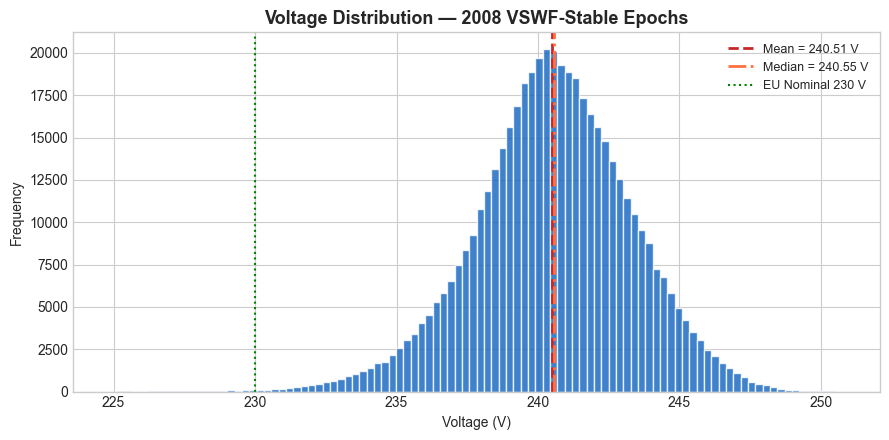

  ✔  Saved: outputs/fig1_voltage_histogram.png


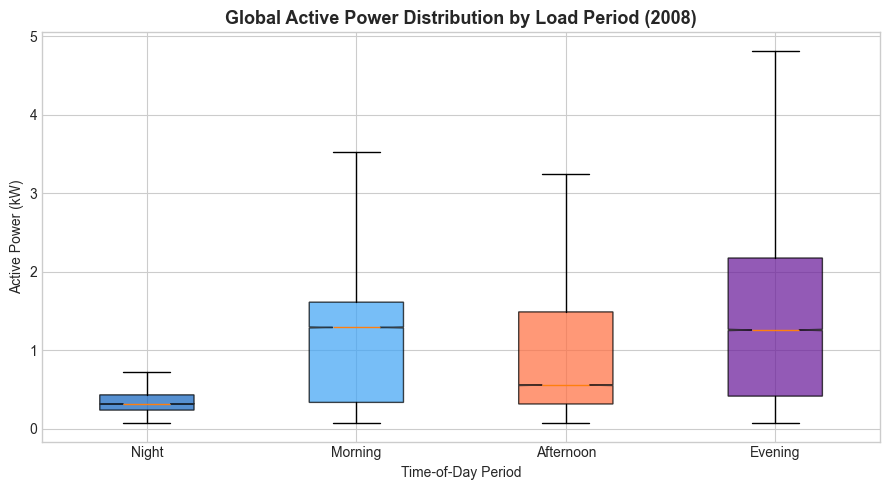

  ✔  Saved: outputs/fig2_power_boxplot_by_period.png


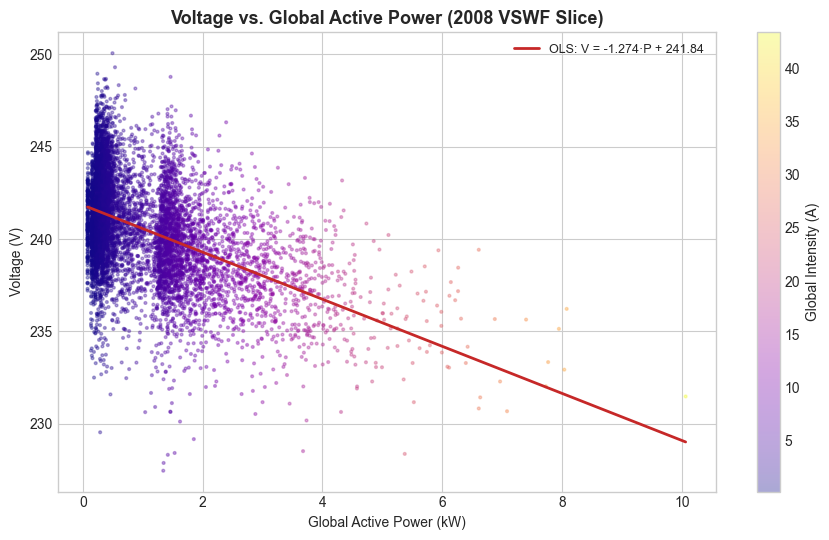

  ✔  Saved: outputs/fig3_voltage_vs_power_scatter.png


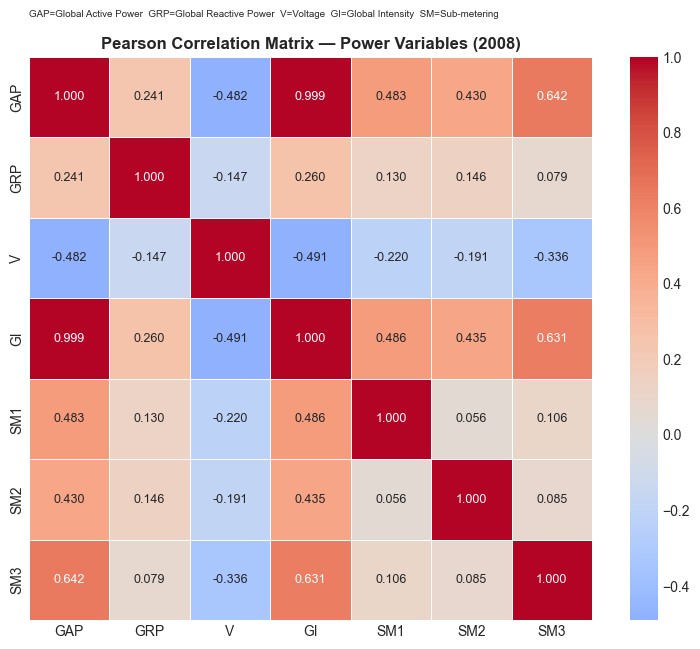

  ✔  Saved: outputs/fig4_correlation_heatmap.png


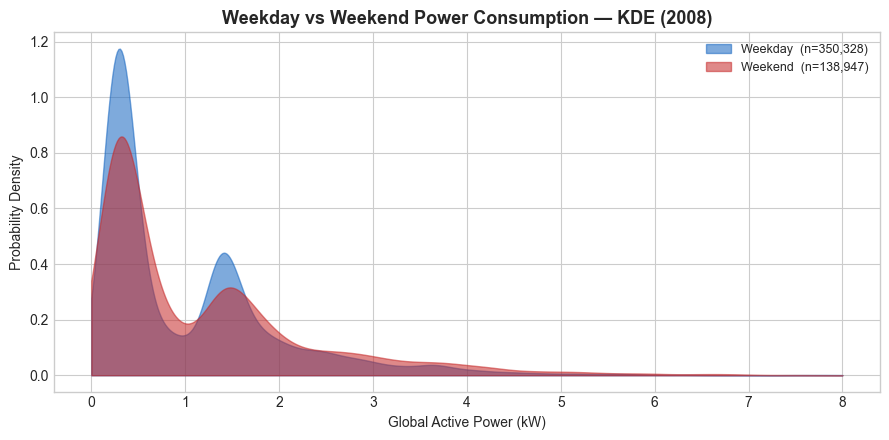

  ✔  Saved: outputs/fig5_weekday_weekend_kde.png


In [9]:
p.plot_static()


════════════════════════════════════════════════════════════
  MODULE 5b — ANIMATED VISUALIZATIONS
════════════════════════════════════════════════════════════


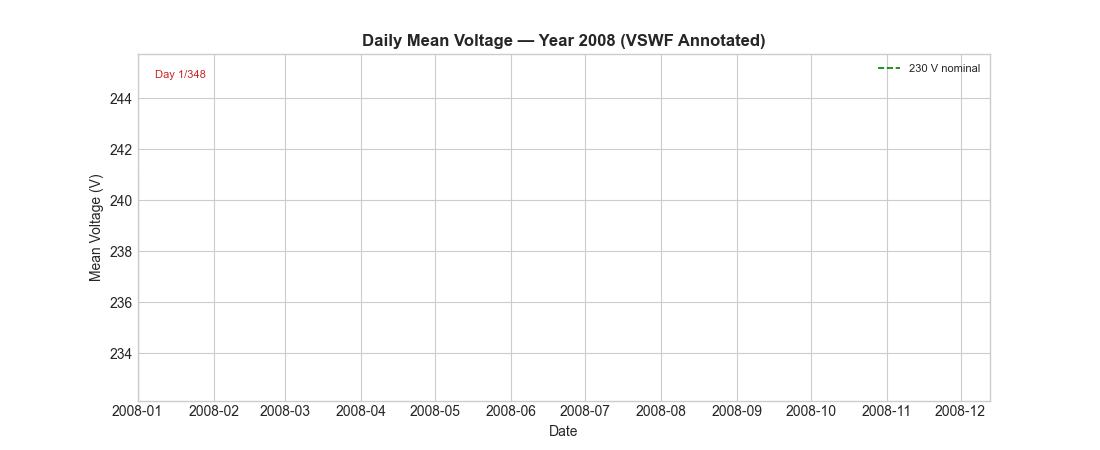

  ✔  Saved: outputs/anim1_daily_voltage_2008.gif


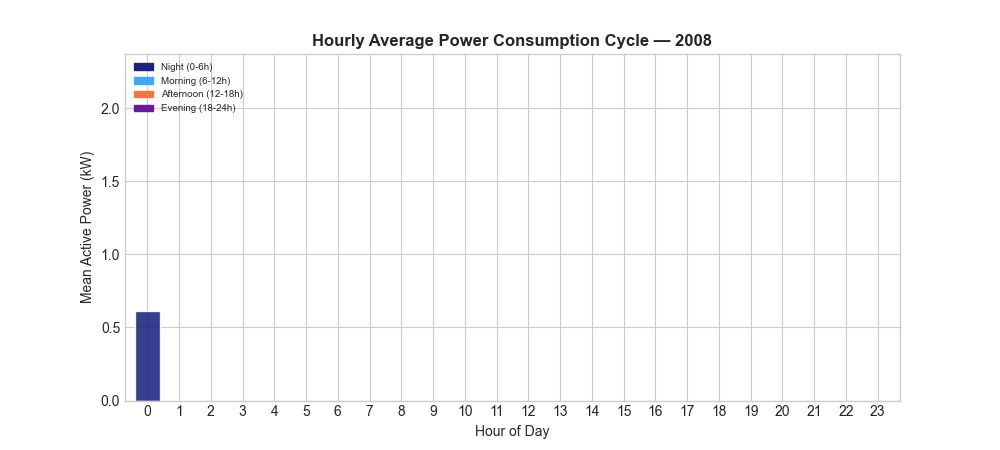

  ✔  Saved: outputs/anim2_hourly_power_cycle.gif


In [10]:
p.plot_animated()